In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

# Better plot size
plt.rcParams["figure.figsize"] = (8,5)


In [10]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Engineering Notes\online_retail_UTF8.csv")

In [43]:
df.head() #First Five rows 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [44]:
df.tail() #Last five rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France


In [14]:
df.shape #(rows,coloumn)

(541909, 8)

In [15]:
df.info() #coloumn info

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [16]:
df.describe() #Statistical Summary

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [17]:
df.isnull().sum() #missing values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [35]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
CustomerID,135037,25.163377
Description,1454,0.270945
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [19]:
df.duplicated().sum() #duplicates values

np.int64(5268)

In [20]:
df.drop_duplicates(inplace=True) #remove

In [21]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [22]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [42]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
#customer id convert into float 
df["CustomerID"] = df["CustomerID"].astype("Int64")

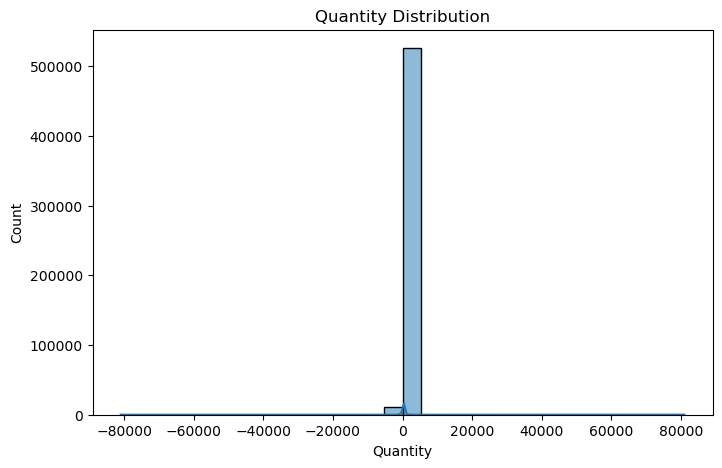

In [24]:
#Quantity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=30, kde=True)
plt.title("Quantity Distribution")
plt.show()

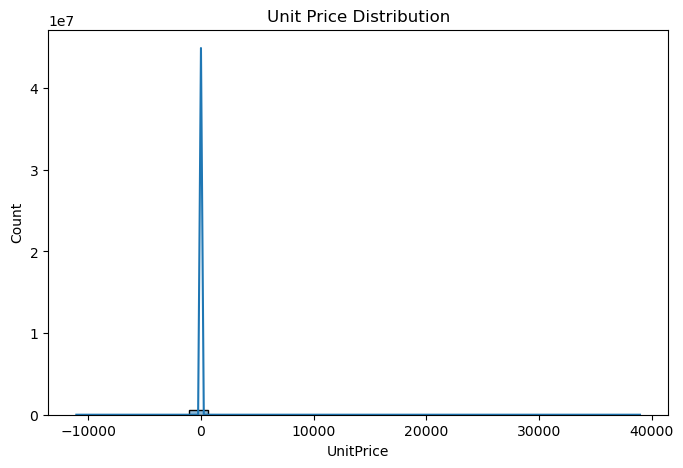

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["UnitPrice"], bins=30, kde=True)
plt.title("Unit Price Distribution")
plt.show()

#boxoplot 

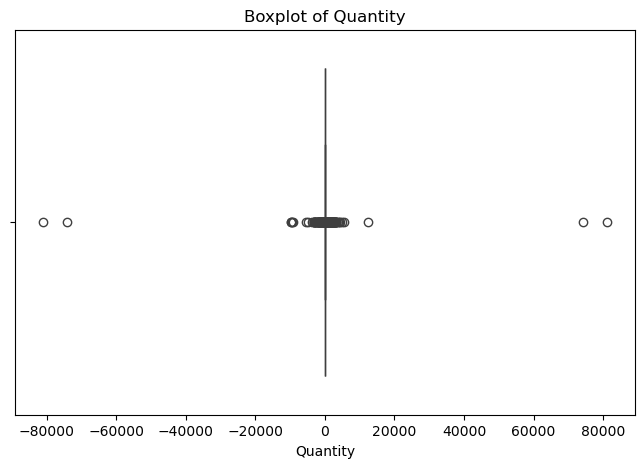

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")

plt.show()

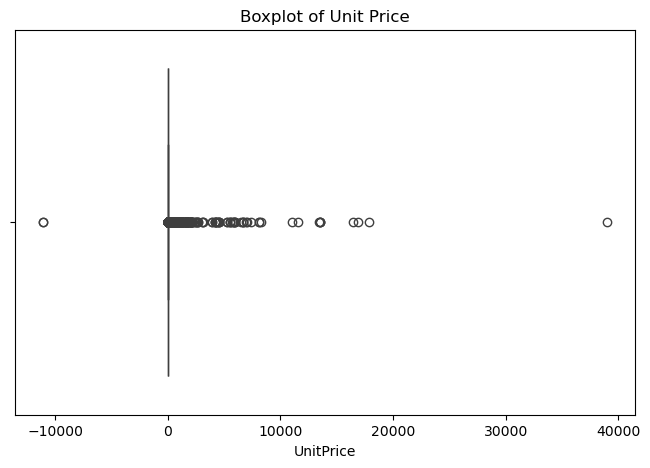

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["UnitPrice"])

plt.title("Boxplot of Unit Price")

plt.show()

#Correlation

In [29]:
corr=df.corr(numeric_only=True)

corr

,Quantity,UnitPrice,CustomerID
Quantity,1.000000,-0.001241,-0.003457
UnitPrice,-0.001241,1.000000,-0.004524
CustomerID,-0.003457,-0.004524,1.000000


#Correlation Heatmap

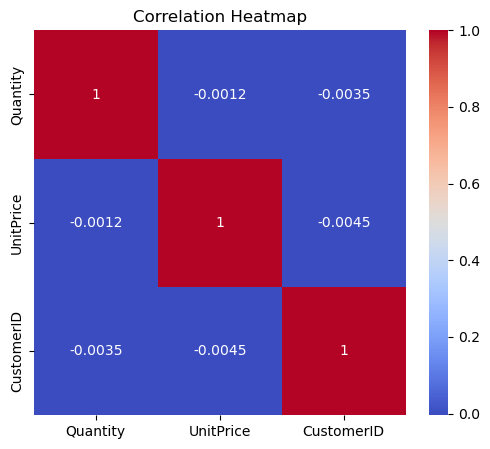

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()



#Country Wise Orders

In [31]:
df["Country"].value_counts().head(10)

Country
United Kingdom    490300
Germany             9480
France              8541
EIRE                8184
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1994
Portugal            1510
Australia           1258
Name: count, dtype: int64

#Plot Top Countries

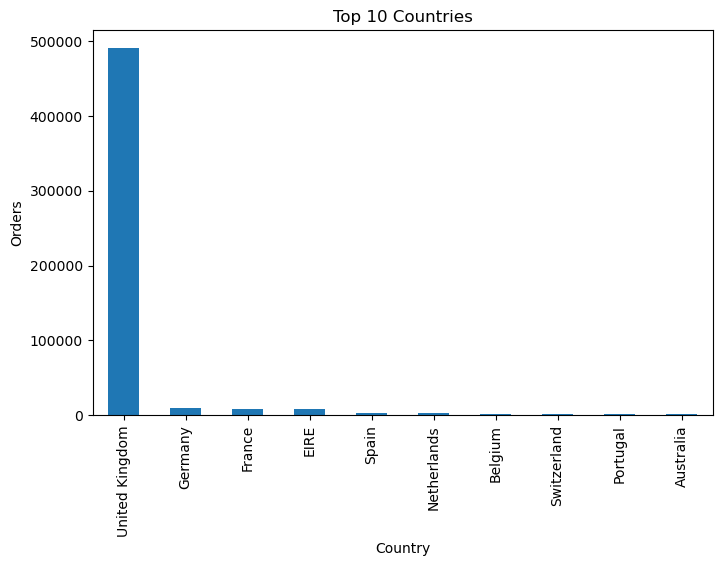

In [32]:
top=df["Country"].value_counts().head(10)

top.plot(kind="bar")

plt.title("Top 10 Countries")

plt.ylabel("Orders")

plt.show()

#Top Selling Products

In [33]:
top_products=df.groupby("Description")["Quantity"].sum()

top_products.sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

#Top 10 Selling  Products

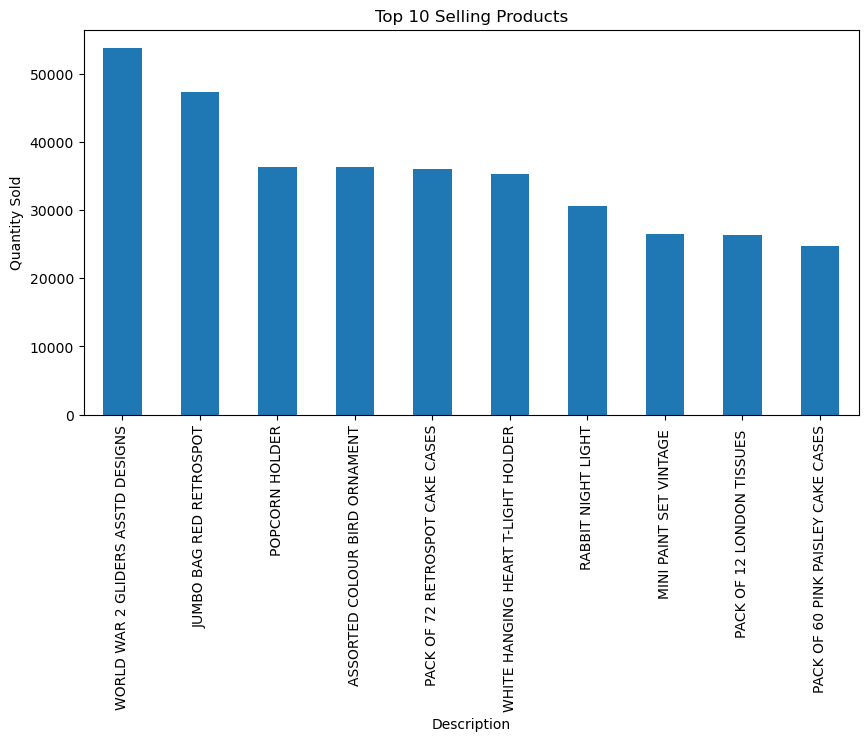

In [39]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")

plt.ylabel("Quantity Sold")

plt.show()

## Business Insights

1. UK has the highest number of transactions.

2. Quantity distribution is highly right-skewed.

3. Unit Price contains several high-value outliers.

4. CustomerID contains missing values.

5. Some Quantity values are negative, indicating returned items.